# Table of content
1. neural bigram model
2. neural trigram model (with best practices as exercise)

In [1]:
from urllib.request import urlopen
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


# Neural Bigram Model

In [ ]:
# 1. Data preprocessing

# reading the file and splitting it into the list "words"
# words = open('../data/names.txt', 'r').read().splitlines() # in case of local file
url = "https://raw.githubusercontent.com/yahya94812/Neural-Language-Modeling/refs/heads/main/data/names.txt"
words = urlopen(url).read().decode("utf-8").splitlines()
print(len(words))
print(min(len(w) for w in words))
print(max(len(w) for w in words))
print(words[:10])

chars = sorted(list(set(''.join(words)))) # unique characters in the dataset
stoi = {s:i+1 for i,s in enumerate(chars)}  # stoi(mapping): string to integer mapping based on index
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Read and prepare data
print(f"Training on {len(words)} words")
vocab_size = len(stoi)

# Create training dataset
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs, device=device)
ys = torch.tensor(ys, device=device)

num_examples = xs.nelement()
# batch_size = 1024 * 8 # no batch is required the mode is too small
print(f'Number of training examples: {num_examples}')


32033
2
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
Using device: cuda
Training on 32033 words
Number of training examples: 228146


In [ ]:
# 2. Defining the model

# Initialize single layer with vocab_size number of neurons (weights matrix)
# single layer of 27 neurons where each neuron accepts 27 inputs and produces 1 output, so the output of the layer is 27 values (logits) that represent the scores for each of the 27 possible next characters 
torch.manual_seed(42)
W = torch.randn((vocab_size, vocab_size), requires_grad=True, device=device) # 27 input features (one-hot encoding) and 27 output features (logits for next character)


In [ ]:
# 3, 4. Training and evaluation

lossi = []
xenc = F.one_hot(xs, num_classes=vocab_size).float()

for epoch in range(100_000):
    # batch = torch.randint(0, num_examples, (batch_size,), device=device) # random batch of indices for stochastic gradient descent
    
    # Forward pass
    logits = xenc @ W
    
    # softmax to get probabilities
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    
    # Loss calculation (negative log likelihood)
    loss = -probs[torch.arange(num_examples, device=device), ys].log().mean()
    
    # Backward pass
    W.grad = None
    loss.backward()
    
    # Update weights
    W.data = W.data - 10 * W.grad
    
    if epoch % 1000 == 0:
        lossi.append(loss.item())
        print(f'Epoch {epoch}: Loss = {loss.item():.4f}')

print(f'loss: {loss.item():.4f}')

plt.plot(range(len(lossi)), lossi)

Epoch 0: Loss = 2.4552
Epoch 1000: Loss = 2.4550
Epoch 2000: Loss = 2.4548
Epoch 3000: Loss = 2.4547


KeyboardInterrupt: 

In [ ]:
# Inference

torch.manual_seed(42)

for i in range(5):
    out = []
    ix = 0  # start with '.'
    
    while True:
        # Get probabilities for next character
        xenc = F.one_hot(torch.tensor([ix], device=device), num_classes=vocab_size).float()
        logits = xenc @ W
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)
        
        # Sample next character
        ix = torch.multinomial(probs, num_samples=1, replacement=True).item()
        
        if ix == 0:  # end token
            break
        out.append(itos[ix])
    
    print(''.join(out))
    

k
itarikyviranon
dadar
er
a


# Neural Trigram Model + Best Practices (exercise)

### Exercises:
1. E01: train a trigram language model, i.e. take two characters as an input to predict the 3rd one. Feel free to use either counting or a neural net. Evaluate the loss; Did it improve over a bigram model?
    ans : yeh i have implemented trigram in both counting and neural net model, and yes trigram eval improve over a bigram model

2. E02: split up the dataset randomly into 80% train set, 10% dev set, 10% test set. Train the bigram and trigram models only on the training set. Evaluate them on dev and test splits. What can you see?
3. E03: use the dev set to tune the strength of smoothing (or regularization) for the trigram model - i.e. try many possibilities and see which one works best based on the dev set loss. What patterns can you see in the train and dev set loss as you tune this strength? Take the best setting of the smoothing and evaluate on the test set once and at the end. How good of a loss do you achieve?
4. E04: we saw that our 1-hot vectors merely select a row of W, so producing these vectors explicitly feels wasteful. Can you delete our use of F.one_hot in favor of simply indexing into rows of W?
5. E05: look up and use F.cross_entropy instead. You should achieve the same result. Can you think of why we'd prefer to use F.cross_entropy instead?
6. E06: meta-exercise! Think of a fun/interesting exercise and complete it.

In [6]:
# 1. Data preprocessing

# reading the file and splitting it into the list "words"
# words = open('../data/names.txt', 'r').read().splitlines() # in case of local file
url = "https://raw.githubusercontent.com/yahya94812/Neural-Language-Modeling/refs/heads/main/data/names.txt"
words = urlopen(url).read().decode("utf-8").splitlines()
print(len(words))
print(min(len(w) for w in words))
print(max(len(w) for w in words))
print(words[:10])

chars = sorted(list(set(''.join(words)))) # unique characters in the dataset
stoi = {s:i+1 for i,s in enumerate(chars)}  # stoi(mapping): string to integer mapping based on index
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Read and prepare data
print(f"Training on {len(words)} words")
vocab_size = len(stoi)

# Create training dataset
import random
random.seed(42)
random.shuffle(words) # imp : it will not return a new list but it will shuffle the original list in place, so we don't need to assign it back to words

X, Y = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        ix3 = stoi[ch3]
        X.append((ix1, ix2))
        Y.append(ix3)

n = len(Y)
n1 = int(n * 0.8)
n2 = int(n * 0.9)

X = torch.tensor(X, device=device)
Y = torch.tensor(Y, device=device)

Xtr, Ytr = X[:n1], Y[:n1]
Xte, Yte = X[n1:n2], Y[n1:n2]
Xdev, Ydev = X[n2:], Y[n2:]

num_examples = Ytr.nelement() # important to use Ytr.nelement() instead of Xtr.nelement() because Xtr is a 2D tensor and Ytr is a 1D tensor, so the number of training examples is determined by the number of elements in Ytr
# batch_size = 1024 * 8 # no batch is required the mode is too small
print(f'Number of training examples: {num_examples}')


32033
2
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
Using device: cuda
Training on 32033 words
Number of training examples: 156890


In [7]:
# 2. Defining the model

# Initialize single layer with vocab_size number of neurons (weights matrix)
# single layer of 27 neurons where each neuron accepts 27 * 2 inputs and produces 1 output, so the output of the layer is 27 values (logits) that represent the scores for each of the 27 possible next characters 
torch.manual_seed(42)
W = torch.randn((vocab_size * 2, vocab_size), requires_grad=True, device=device) # 27 * 2 input features (one-hot encoding) and 27 output features (logits for next character)


Epoch 0: Loss = 2.2373
Epoch 1000: Loss = 2.2372
Epoch 2000: Loss = 2.2371
Epoch 3000: Loss = 2.2371
Epoch 4000: Loss = 2.2370
Epoch 5000: Loss = 2.2370
Epoch 6000: Loss = 2.2369
Epoch 7000: Loss = 2.2369
Epoch 8000: Loss = 2.2369
Epoch 9000: Loss = 2.2369
Epoch 10000: Loss = 2.2368
Epoch 11000: Loss = 2.2368
Epoch 12000: Loss = 2.2368
Epoch 13000: Loss = 2.2368
Epoch 14000: Loss = 2.2368
Epoch 15000: Loss = 2.2367
Epoch 16000: Loss = 2.2367
Epoch 17000: Loss = 2.2367
Epoch 18000: Loss = 2.2367
Epoch 19000: Loss = 2.2367
Epoch 20000: Loss = 2.2367
Epoch 21000: Loss = 2.2367
Epoch 22000: Loss = 2.2367
Epoch 23000: Loss = 2.2367
Epoch 24000: Loss = 2.2367
Epoch 25000: Loss = 2.2366
Epoch 26000: Loss = 2.2366
Epoch 27000: Loss = 2.2366
Epoch 28000: Loss = 2.2366
Epoch 29000: Loss = 2.2366
Epoch 30000: Loss = 2.2366
Epoch 31000: Loss = 2.2366
Epoch 32000: Loss = 2.2366
Epoch 33000: Loss = 2.2366
Epoch 34000: Loss = 2.2366
Epoch 35000: Loss = 2.2366
Epoch 36000: Loss = 2.2366
Epoch 37000: L

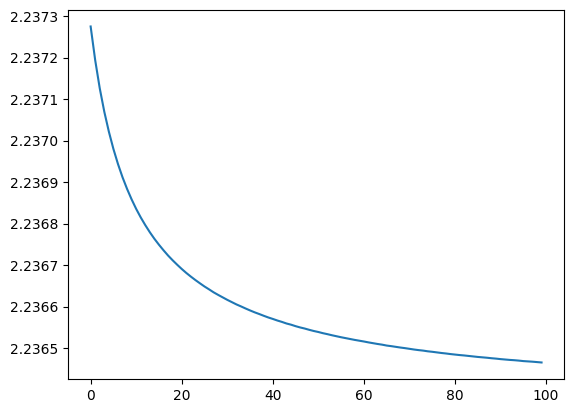

In [11]:
# 3, 4. Training and evaluation

lossi = []

xenc1 = F.one_hot(Xtr[:, 0], num_classes=vocab_size).float() # (num_examples, 27)
xenc2 = F.one_hot(Xtr[:, 1], num_classes=vocab_size).float()
xenc = torch.cat((xenc1, xenc2), dim=1) # (num_examples, 27 * 2)

for epoch in range(100_000):
    # batch = torch.randint(0, num_examples, (batch_size,), device=device) # random batch of indices for stochastic gradient descent
    
    # Forward pass
    logits = xenc @ W
    
    # softmax to get probabilities
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    
    # Loss calculation (negative log likelihood)
    loss = -probs[torch.arange(num_examples, device=device), Ytr].log().mean()
    
    # Backward pass
    W.grad = None
    loss.backward()
    
    # Update weights
    W.data = W.data - 10 * W.grad
    
    if epoch % 1000 == 0:
        lossi.append(loss.item())
        print(f'Epoch {epoch}: Loss = {loss.item():.4f}')

print(f'loss: {loss.item():.4f}')

plt.plot(range(len(lossi)), lossi)

In [10]:
# 4. Evaluation

@torch.no_grad()
def evaluate(X, Y):
    xenc1 = F.one_hot(X[:, 0], num_classes=vocab_size).float() # (num_examples, 27)
    xenc2 = F.one_hot(X[:, 1], num_classes=vocab_size).float()
    xenc = torch.cat((xenc1, xenc2), dim=1) # (num_examples, 27 * 2)
    
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    
    loss = -probs[torch.arange(Y.nelement(), device=device), Y].log().mean()
    
    print(f'Loss: {loss.item():.4f}')

evaluate(Xte, Yte)
evaluate(Xdev, Ydev)

Loss: 2.2369
Loss: 2.2431


In [ ]:
# Inference

torch.manual_seed(42)

for i in range(5):
    out = []
    ix1 = 0  # start with '.'
    ix2 = 0  # start with '.'
    
    while True:
        # Get probabilities for next character
        xenc1 = F.one_hot(torch.tensor([ix1], device=device), num_classes=vocab_size).float()
        xenc2 = F.one_hot(torch.tensor([ix2], device=device), num_classes=vocab_size).float()
        xenc = torch.cat((xenc1, xenc2), dim=1)
        
        logits = xenc @ W
        counts = logits.exp()
        probs = counts / counts.sum(1, keepdims=True)
        
        # Sample next character
        ix3 = torch.multinomial(probs, num_samples=1, replacement=True).item()
        
        if ix3 == 0:  # end token
            break
        out.append(itos[ix3])
        
        ix1 = ix2
        ix2 = ix3
    
    print(''.join(out))
    

leitarikyviranoe
oudar
er
oumairishiay
oriellive
